____
# Spatial scales


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
max_ggd = 1e-4
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Gaussian

In [3]:
#GAUSSIAN
cutoff = np.arange(5e3, 60e3, 5e3)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'gaussian',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DSG = DSG.rename({'id_comb':'cutoff'})
DSG['cutoff'] = DSG.cutoff/1000
DSG['cutoff'] = DSG['cutoff'].assign_attrs({'long_name': 'Gaussian filter cutoff', 'units':'km'})


# Closure figs
dsg = compute_mean_square(DSG)/U2



313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_5000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_10000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_15000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_20000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_25000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_30000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_35000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_40000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_45000_etaf__era5_rio0
313260
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_50000_etaf__era5_rio0
313260
12h_spectral_d

In [6]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


Text(0, 0.5, '[$\\gamma^2$]')

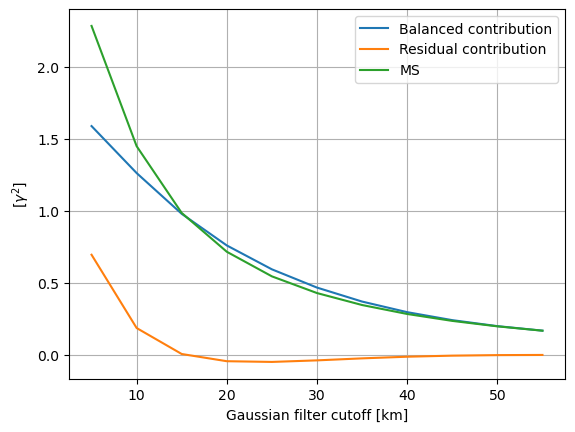

In [4]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution')
dsg.E_ggd.plot(ax=ax, label = 'Residual contribution')
dsg.GGD.plot(ax=ax, label = 'MS')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Fitting kernel

In [5]:
#FITTING KERNEL
npts = np.arange(5, 19, 2)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fitting_kernel',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',npts)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',npts)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSF = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


DSF = DSF.rename({'id_comb':'npts'})
DSF['npts'] = DSF.npts
DSF['npts'] = DSF['npts'].assign_attrs({'long_name': 'Fitting kernel number of points', 'units':'npts'})


# Closure figs
dsf = compute_mean_square(DSF)/U2


289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio0
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio0
264246
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_9_etaf__era5_rio0
250794
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_11_etaf__era5_rio0
237840
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_13_etaf__era5_rio0
223946
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_15_etaf__era5_rio0
210192
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_17_etaf__era5_rio0
Identified SWOT and drifter outliers have been removed
289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio15
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio15
264246
12h_spectral_decomp_all_med_vari

Text(0, 0.5, '[$\\gamma^2$]')

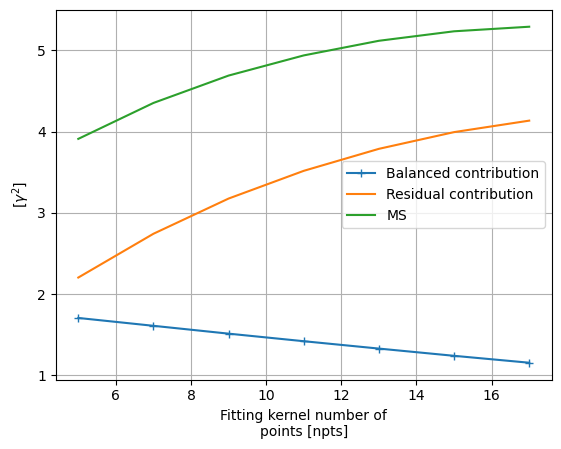

In [6]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsf.B_ggd.plot(ax=ax, label = 'Balanced contribution', marker='+')
dsf.E_ggd.plot(ax=ax, label = 'Residual contribution')
dsf.GGD.plot(ax=ax, label = 'MS')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Others

In [5]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [base_dic, 
             update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
             update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
             update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),    
]

l = ['L3-SWOT 2km', 'L4_noswot_regional', 'L4_noswot_global', 'L4_withnadirswot']

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS4 = DS4.rename({'id_comb':'altiprod'})
DS4['altiprod'] = DS4['altiprod'].assign_attrs({'long_name': 'Altimetric products'})


# Closure figs
ds4 = compute_mean_square(DS4)/U2

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
373036
12h_spectral_decomp_all_med_variational_10min_v0____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_glo

In [8]:
ds4

<xarray.Dataset> Size: 5kB
Dimensions:            (altiprod: 4)
Coordinates:
  * altiprod           (altiprod) <U18 288B 'L3-SWOT 2km' ... 'L4_withnadirswot'
Data variables: (12/132)
    ACCn               (altiprod) float64 32B 1.797 1.797 1.797 1.797
    CORn               (altiprod) float64 32B 3.322 3.322 3.322 3.322
    GGDn               (altiprod) float64 32B 1.749 0.5694 0.4318 0.6312
    WDn                (altiprod) float64 32B 0.1204 0.1204 0.1204 0.1204
    Sn                 (altiprod) float64 32B 1.396 1.492 1.541 1.412
    ACCe               (altiprod) float64 32B 1.672 1.672 1.672 1.672
    ...                 ...
    ser__X_acc_wd      (altiprod) float64 32B 0.008758 0.008758 ... 0.008758
    ser__X_cor_ggd     (altiprod) float64 32B 0.03049 0.01573 0.01392 0.0172
    ser__X_cor_wd      (altiprod) float64 32B 0.02094 0.02094 0.02094 0.02094
    ser__X_ggd_wd      (altiprod) float64 32B 0.008094 0.003519 ... 0.003813
    ser__D_cyclo       (altiprod) float64 32B 0.0268 0.01349 0.01204 0.01489
    ser__D_anticyclo   (altiprod) float64 32B 0.05163 0.04229 0.04135 0.04322

# All together

Text(0, 0.5, '[$\\gamma^2$]')

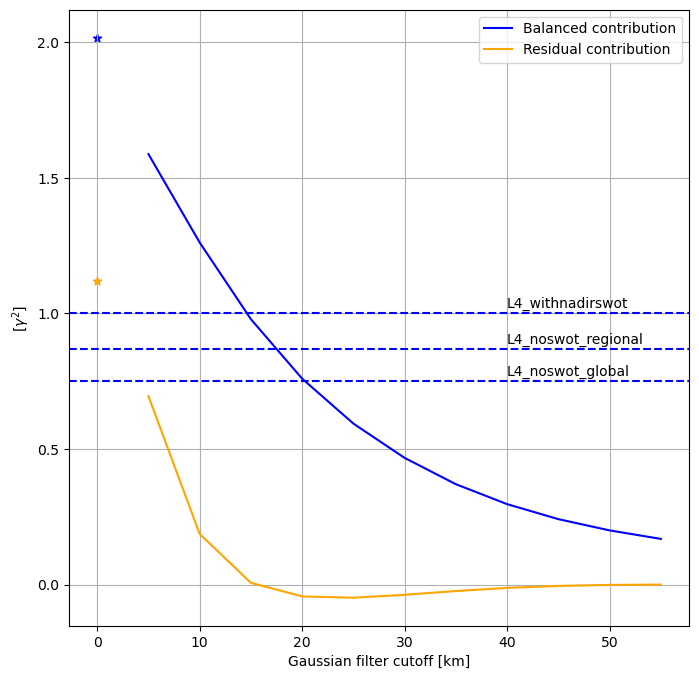

In [24]:
fig, ax = plt.subplots(1,1, figsize=(8,8))
dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution', color='b')
dsg.E_ggd.plot(ax=ax, label = 'Residual contribution', color='orange')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker = '*', c='b')
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker = '*', c='orange')
#dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[1:]:
    ax.axhline(ds4.sel(altiprod=ap).B_ggd, ls='--',  color='b')
    ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    #ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    #ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

Text(0, 0.5, '[$\\gamma^2$]')

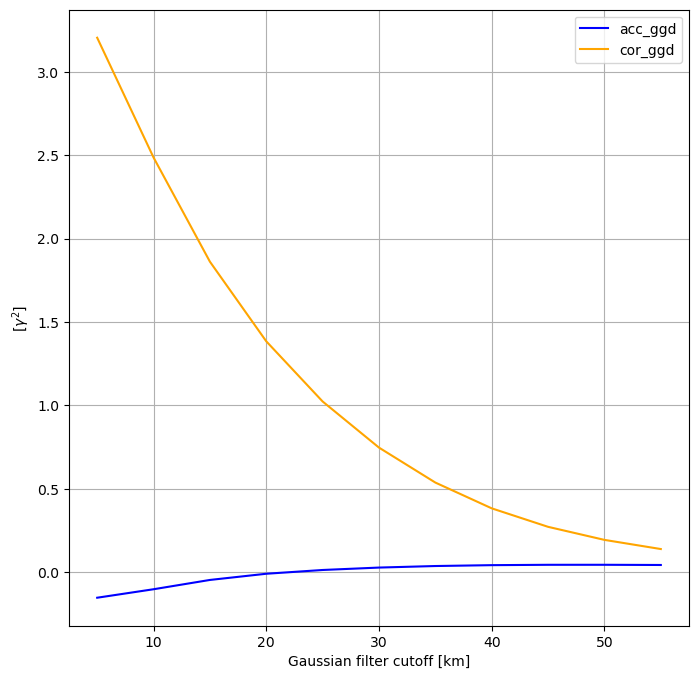

In [31]:
fig, ax = plt.subplots(1,1, figsize=(8,8))
dsg.X_acc_ggd.plot(ax=ax, label = 'acc_ggd', color='b')
dsg.X_cor_ggd.plot(ax=ax, label = 'cor_ggd', color='orange')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# With time to swot bins

In [29]:
D =[]
D.append(compute_mean_square(DSG.where(DSG.time_to_swot<pd.Timedelta('6h'), drop=True))/U2)
D.append(compute_mean_square(DSG.where(DSG.time_to_swot>pd.Timedelta('6h'), drop=True))/U2)

Text(0, 0.5, '[$\\gamma^2$]')

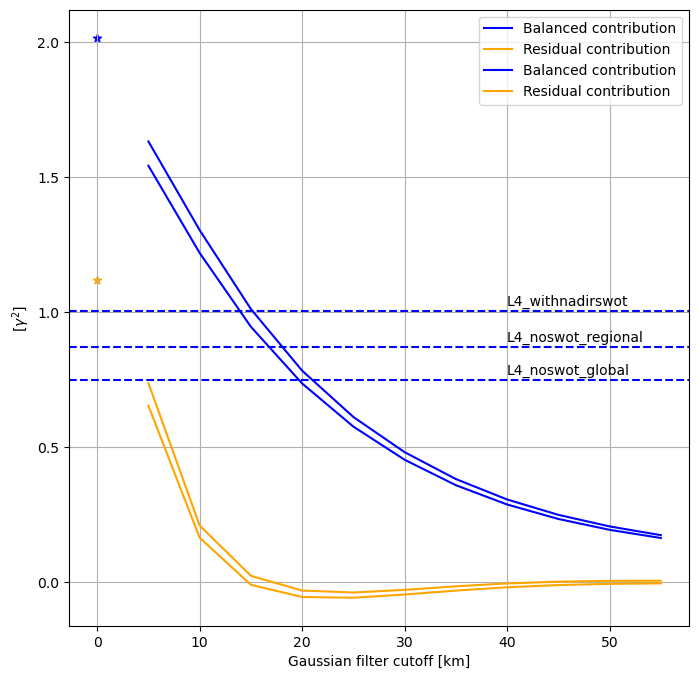

In [30]:
fig, ax = plt.subplots(1,1, figsize=(8,8))

for dsg in D:
    dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution', color='b')
    dsg.E_ggd.plot(ax=ax, label = 'Residual contribution', color='orange')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker = '*', c='b')
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker = '*', c='orange')
#dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[1:]:
    ax.axhline(ds4.sel(altiprod=ap).B_ggd, ls='--',  color='b')
    ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    #ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    #ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')